<a href="https://colab.research.google.com/github/panavgohil/ML-Assignment-1/blob/main/House_Price_Prediction_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVR, SVC
from sklearn.linear_model import SGDRegressor, SGDClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)


In [2]:
!pip install imbalanced-learn  #SMOTE Library

In [3]:
from imblearn.over_sampling import SMOTE    #SMOTE creates artificial samples of the minority class, model learns fairly

In [4]:
from google.colab import files
uploaded = files.upload()

Saving kc_house_data.csv to kc_house_data.csv


In [5]:
#load Dataset

df = pd.read_csv("kc_house_data.csv")

print("Rows:", len(df))
print("Columns:", df.shape[1])

df.head()


Rows: 21613
Columns: 21


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [7]:
#data preprocessing -->cleanup extra columns
# Remove unnecessary columns

for col in ["id", "date"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True) #inplace=True -->modify in same dataframe

df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [8]:
df.isnull().sum()

,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0
grade,0


In [9]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [10]:
TARGET = "price"

FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES].copy()
y_reg = df[TARGET].copy()

In [11]:
print(X.shape)
print(y_reg.shape)

(21613, 18)
(21613,)


In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test=train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (17290, 18)
Testing data : (4323, 18)


In [13]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [14]:
print(X_train.iloc[0])
print("\nScaled:\n")
print(X_train_scaled[0])

bedrooms             3.000
bathrooms            1.750
sqft_living       1780.000
sqft_lot         13095.000
floors               1.000
waterfront           0.000
view                 0.000
condition            4.000
grade                9.000
sqft_above        1780.000
sqft_basement        0.000
yr_built          1983.000
yr_renovated         0.000
zipcode          98042.000
lat                 47.367
long              -122.152
sqft_living15     2750.000
sqft_lot15       13095.000
Name: 6325, dtype: float64

Scaled:

[-0.39526335 -0.47445144 -0.32393262 -0.04387306 -0.91959976 -0.08499166
 -0.30591651  0.90907268  1.15024328 -0.00725676 -0.65631017  0.40400107
 -0.20829394 -0.6746308  -1.39660754  0.44228847  1.12607326  0.01344043]


In [15]:
#dividing house prices into low, mid, and high categories
q33=y_reg.quantile(.33)
q66=y_reg.quantile(.66)
print("33rd percentile",q33)
print("66th percentile",q66)

33rd percentile 360000.0
66th percentile 560000.0


In [16]:
y_cls=pd.cut(
    y_reg,
    bins=[-np.inf, q33,q66,np.inf],
    labels=["low","mid","high"]
)
print(y_cls.head(10))

0     low
1     mid
2     low
3    high
4     mid
5    high
6     low
7     low
8     low
9     low
Name: price, dtype: category
Categories (3, object): ['low' < 'mid' < 'high']


In [17]:
print(y_cls.value_counts())

price
high    7296
low     7226
mid     7091
Name: count, dtype: int64


In [18]:
mask_high=y_cls=='high'
drop_idx=y_cls[mask_high].sample(
    frac=0.55,
    random_state=42
).index
df_bal=df.drop(index=drop_idx).reset_index(drop=True)
print("Original rows:", len(df))
print("New rows:", len(df_bal))

Original rows: 21613
New rows: 17600


In [19]:
X_cls=df_bal[FEATURES].copy()
y_cls2=pd.cut(
    df_bal["price"],
    bins=[-np.inf,q33,q66,np.inf],
    labels=["low","mid","high"]
)

In [20]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y_cls_enc=le.fit_transform(y_cls2)
print("classes:",le.classes_)
print("First 10 labels:",y_cls_enc[:10])

classes: ['high' 'low' 'mid']
First 10 labels: [1 2 1 2 0 1 1 1 1 0]


In [21]:
import numpy as np

print(
    dict(
        zip(
            le.classes_,
            np.bincount(y_cls_enc)
        )
    )
)

{'high': np.int64(3283), 'low': np.int64(7226), 'mid': np.int64(7091)}


In [22]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls,
    y_cls_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_cls_enc
)

In [23]:
scaler_c = StandardScaler()

X_train_c_s = scaler_c.fit_transform(X_train_c)
X_test_c_s = scaler_c.transform(X_test_c)

In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_c_sm, y_train_c_sm = smote.fit_resample(
    X_train_c_s,
    y_train_c
)

In [25]:
print("Before SMOTE:")
print(dict(zip(le.classes_, np.bincount(y_train_c))))

print("\nAfter SMOTE:")
print(dict(zip(le.classes_, np.bincount(y_train_c_sm))))

Before SMOTE:
{'high': np.int64(2626), 'low': np.int64(5781), 'mid': np.int64(5673)}

After SMOTE:
{'high': np.int64(5781), 'low': np.int64(5781), 'mid': np.int64(5781)}


In [26]:
#svc
from sklearn.svm import SVC
svc = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)
svc.fit(
    X_train_c_sm,
    y_train_c_sm
)

SVC(C=10, class_weight='balanced', random_state=42)

In [27]:
y_pred_svc = svc.predict(X_test_c_s)

In [28]:
from sklearn.metrics import classification_report
print(
    classification_report(
        y_test_c,
        y_pred_svc,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

        high       0.79      0.84      0.81       657
         low       0.89      0.85      0.87      1445
         mid       0.78      0.80      0.79      1418

    accuracy                           0.83      3520
   macro avg       0.82      0.83      0.82      3520
weighted avg       0.83      0.83      0.83      3520



In [29]:
accuracy=np.mean(y_pred_svc==y_test_c)
print(
    f"Accuracy: {accuracy*100:.2f}%"
)

Accuracy: 82.53%


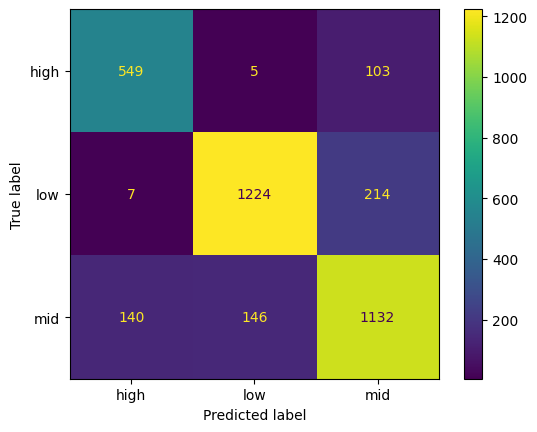

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test_c,
    y_pred_svc
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot()
plt.show()

In [31]:
#svr
svr = SVR(
    kernel="rbf",
    C=100000,
    epsilon=0.01,
    gamma=0.01
)
svr.fit(
    X_train_scaled,
    y_train
)

SVR(C=100000, epsilon=0.01, gamma=0.01)

In [32]:
y_pred_svr = svr.predict(X_test_scaled)

In [33]:
mae=mean_absolute_error(
    y_test,
    y_pred_svr
)
rmse=np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_svr
    )
)
r2=r2_score(
    y_test,
    y_pred_svr
)
print("MAE: ",mae)
print("RMSE: ",rmse)
print("R^2  :", r2)

MAE:  101499.61055102888
RMSE:  196691.43892986083
R^2  : 0.7440907295128419


In [34]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score

svr_t1 = SVR(
    kernel='rbf',
    C=1000,
    epsilon=0.01,
    gamma='scale'
)

svr_t1.fit(X_train_scaled, y_train)

y_pred_t1 = svr_t1.predict(X_test_scaled)

print("Trial 1 R²:", r2_score(y_test, y_pred_t1))

Trial 1 R²: 0.3284091984567037


In [35]:
svr_t2 = SVR(
    kernel='rbf',
    C=10000,
    epsilon=0.01,
    gamma='scale'
)

svr_t2.fit(X_train_scaled, y_train)

y_pred_t2 = svr_t2.predict(X_test_scaled)

print("Trial 2 R²:", r2_score(y_test, y_pred_t2))

Trial 2 R²: 0.5050582996967576


In [36]:
svr_t3 = SVR(
    kernel='rbf',
    C=50000,
    epsilon=0.01,
    gamma='scale'
)

svr_t3.fit(X_train_scaled, y_train)

y_pred_t3 = svr_t3.predict(X_test_scaled)

print("Trial 3 R²:", r2_score(y_test, y_pred_t3))

Trial 3 R²: 0.6396886846522202


In [37]:
svr_t4 = SVR(
    kernel='rbf',
    C=100000,
    epsilon=0.01,
    gamma='scale'
)

svr_t4.fit(X_train_scaled, y_train)
y_pred_t4 = svr_t4.predict(X_test_scaled)

print("Trial 4 R²:", r2_score(y_test, y_pred_t4))

Trial 4 R²: 0.6912408212401033


In [38]:
svr_t5 = SVR(
    kernel='rbf',
    C=200000,
    epsilon=0.001,
    gamma='scale'
)

svr_t5.fit(X_train_scaled, y_train)

y_pred_t5 = svr_t5.predict(X_test_scaled)

print("Trial 5 R²:", r2_score(y_test, y_pred_t5))

Trial 5 R²: 0.729985830817722


In [39]:
svr_t6 = SVR(
    kernel='rbf',
    C=100000,
    epsilon=0.01,
    gamma=0.01
)

svr_t6.fit(X_train_scaled, y_train)

y_pred_t6 = svr_t6.predict(X_test_scaled)

print("Trial 6 R²:", r2_score(y_test, y_pred_t6))

Trial 6 R²: 0.7440907295128419


In [40]:
svr_t7 = SVR(
    kernel='rbf',
    C=100000,
    epsilon=0.01,
    gamma=0.1
)

svr_t7.fit(X_train_scaled, y_train)

y_pred_t7 = svr_t7.predict(X_test_scaled)

print("Trial 7 R²:", r2_score(y_test, y_pred_t7))

Trial 7 R²: 0.6208950959093806


In [41]:
svr_t8 = SVR(
    kernel='rbf',
    C=100000,
    epsilon=0.1,
    gamma='scale'
)

svr_t8.fit(X_train_scaled, y_train)

y_pred_t8 = svr_t8.predict(X_test_scaled)

print("Trial 8 R²:", r2_score(y_test, y_pred_t8))

Trial 8 R²: 0.6912408226799749


In [42]:
svr_t9 = SVR(
    kernel='rbf',
    C=100000,
    gamma=0.005,
    epsilon=0.01
)

svr_t9.fit(X_train_scaled, y_train)

y_pred_t9 = svr_t9.predict(X_test_scaled)

print("Trial 9 R²:", r2_score(y_test, y_pred_t9))

Trial 9 R²: 0.7314853476398184


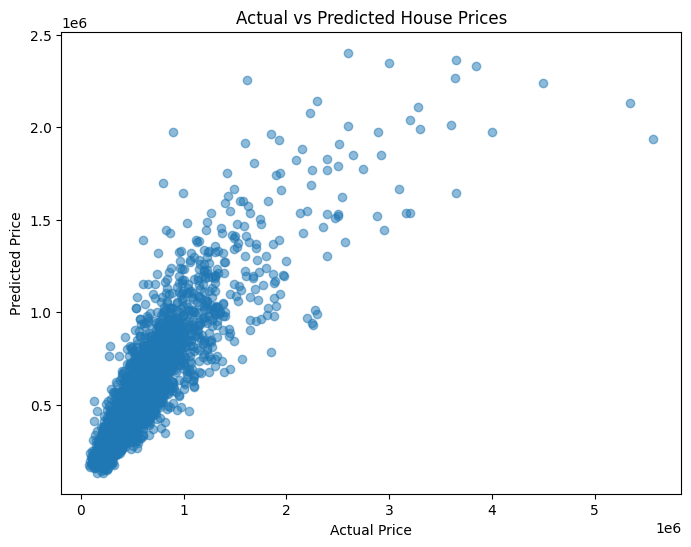

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_svr,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

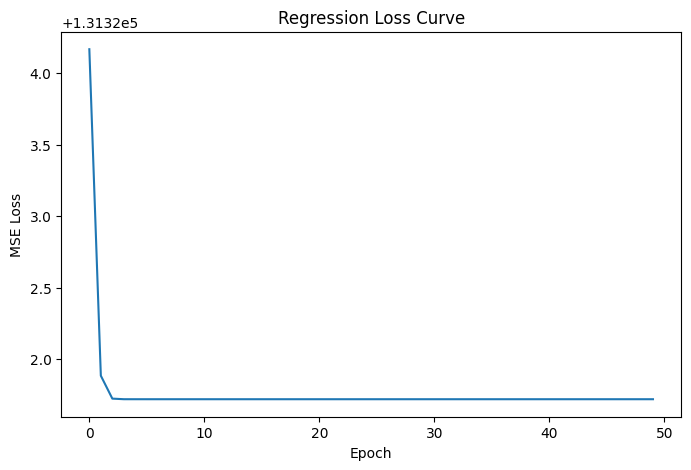

In [46]:
#Regression Loss Curve
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(
    max_iter=1,
    tol=None,
    random_state=42,
    warm_start=True
)
train_loss_reg = []
for epoch in range(50):
    sgd_reg.fit(X_train_scaled, y_train)
    pred = sgd_reg.predict(X_train_scaled)
    train_loss_reg.append(
        mean_absolute_error(y_train, pred)
    )
plt.figure(figsize=(8,5))
plt.plot(train_loss_reg)
plt.title("Regression Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

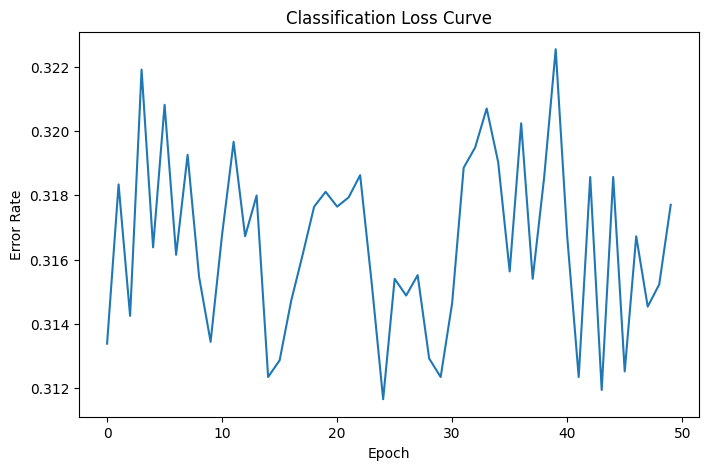

In [47]:
#Classification Loss Curve
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(
    loss="log_loss",
    max_iter=1,
    tol=None,
    random_state=42,
    warm_start=True
)
train_loss_cls = []
for epoch in range(50):
    sgd_clf.fit(X_train_c_sm, y_train_c_sm)
    pred = sgd_clf.predict(X_train_c_sm)
    train_loss_cls.append(
        1 - np.mean(pred == y_train_c_sm)
    )
plt.figure(figsize=(8,5))
plt.plot(train_loss_cls)
plt.title("Classification Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Error Rate")
plt.show()

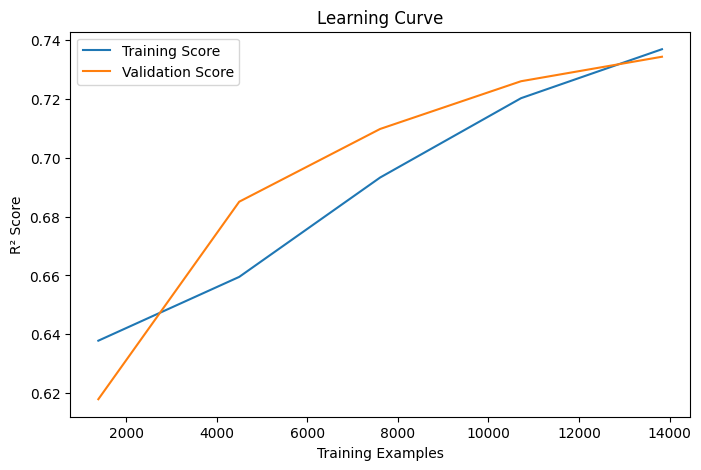

In [48]:
#Learning Curve
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(
    SVR(
        kernel='rbf',
        C=100000,
        gamma=0.01,
        epsilon=0.01
    ),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)
plt.figure(figsize=(8,5))
plt.plot(
    train_sizes,
    train_scores.mean(axis=1),
    label="Training Score"
)
plt.plot(
    train_sizes,
    test_scores.mean(axis=1),
    label="Validation Score"
)
plt.legend()
plt.title("Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("R² Score")
plt.show()

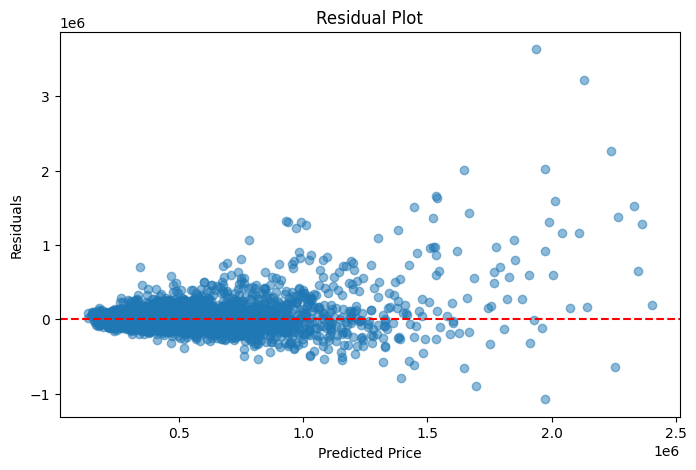

In [49]:
#Residual Plot
residuals = y_test - y_pred_svr
plt.figure(figsize=(8,5))
plt.scatter(
    y_pred_svr,
    residuals,
    alpha=0.5
)
plt.axhline(
    y=0,
    color='r',
    linestyle='--'
)
plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.show()

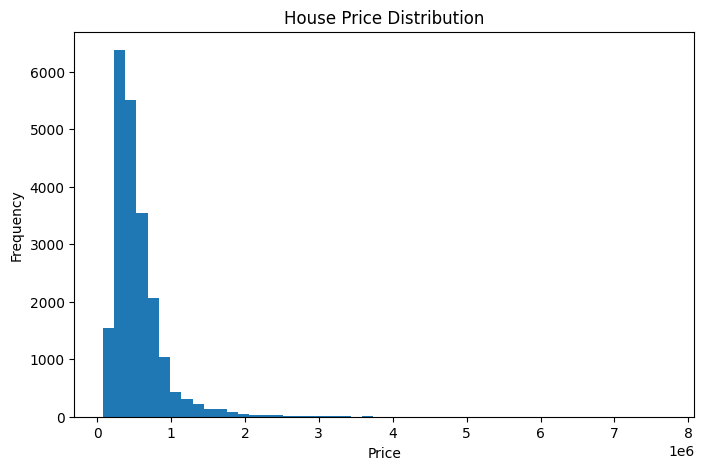

In [50]:
#Price Distribution
plt.figure(figsize=(8,5))
plt.hist(
    y_reg,
    bins=50
)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

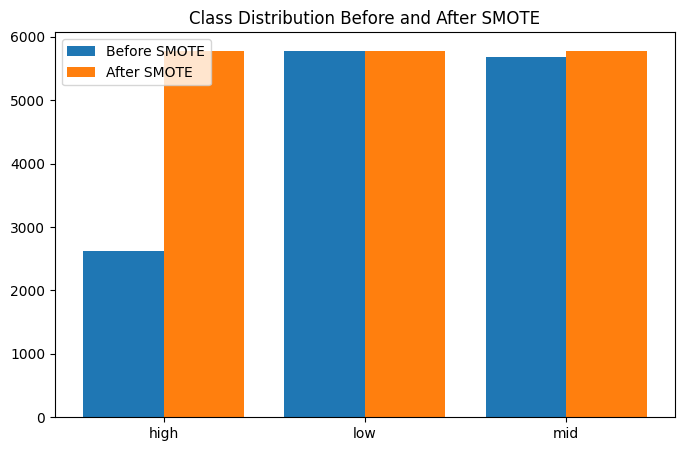

In [51]:
#Before vs After SMOTE Visualization
before_counts = np.bincount(y_train_c)
after_counts = np.bincount(y_train_c_sm)
x = np.arange(len(le.classes_))
plt.figure(figsize=(8,5))
plt.bar(
    x - 0.2,
    before_counts,
    width=0.4,
    label="Before SMOTE"
)
plt.bar(
    x + 0.2,
    after_counts,
    width=0.4,
    label="After SMOTE"
)
plt.xticks(x, le.classes_)
plt.legend()
plt.title("Class Distribution Before and After SMOTE")
plt.show()

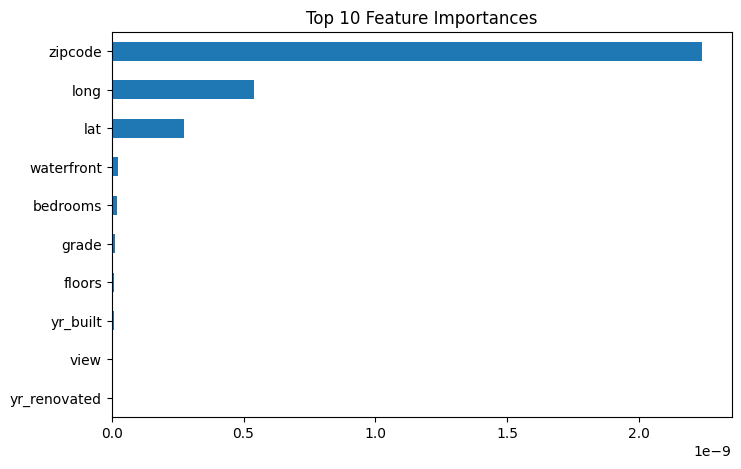

In [52]:
#Feature Importance (LinearSVR)
from sklearn.svm import LinearSVR
lin_svr = LinearSVR(
    random_state=42,
    max_iter=10000
)
lin_svr.fit(
    X_train_scaled,
    y_train
)
importance = pd.Series(
    np.abs(lin_svr.coef_),
    index=FEATURES
)
importance.sort_values().tail(10).plot(
    kind="barh",
    figsize=(8,5)
)
plt.title("Top 10 Feature Importances")
plt.show()

# House Sales Prediction and Classification using SVM

## Name: Panav Gohil
## Roll number: 25/A14/031

### Objective
To predict house prices using Support Vector Regression (SVR) and classify houses into price categories using Support Vector Classification (SVC). The project also demonstrates handling imbalanced data using SMOTE.